CS 422 Overwatch Simple Model

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Display stuff for easy edits

In [115]:
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

Set up teams

In [116]:
df = pd.read_csv("Reduced_Stats.csv")

In [117]:
print(f"Original dataset shape: {df.shape}")
print(f"Expected number of games: {df.shape[0] // 10}")

Original dataset shape: (6110, 14)
Expected number of games: 611


In [118]:
features = [
    "Eliminations", "Damage Dealt", "Assists", "Objective Time",
    "Damage Mitigated", "Healing Done", "Deaths",
    "Solo Kills", "Final Blows"
]

In [119]:
team_stats = df.groupby(
    ["match_id", "round_num", "team"]
)[features].sum().reset_index()

team_results = df.groupby(
    ["match_id", "round_num", "team"]
)["Result"].first().reset_index()

In [120]:
team_data_frame = team_stats.merge(
    team_results,
    on=["match_id", "round_num", "team"]
)

In [121]:
grouped = team_data_frame.groupby(["match_id", "round_num"])

In [122]:
X_rows = []
y_rows = []

for (match, round_), group in grouped:

    if len(group) != 2:
        continue

    t1 = group.iloc[0]
    t2 = group.iloc[1]

    diff = t1[features] - t2[features]

    X_rows.append(diff.values)
    y_rows.append(int(t1["Result"]))

In [123]:
X = pd.DataFrame(X_rows, columns=features)
y = pd.Series(y_rows)

Train/Split here

In [124]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scale

In [125]:
scaler = StandardScaler()

In [126]:
X_train = scaler.fit_transform(X_train)

In [127]:
X_test = scaler.transform(X_test)

Train

In [128]:
model = LogisticRegression(max_iter=5000)

In [129]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Predict

In [130]:
y_pred = model.predict(X_test)

Evaluation

MODEL PERFORMANCE (Logistic Regression)
Accuracy: 89.34%
F1 Score : 88.29%


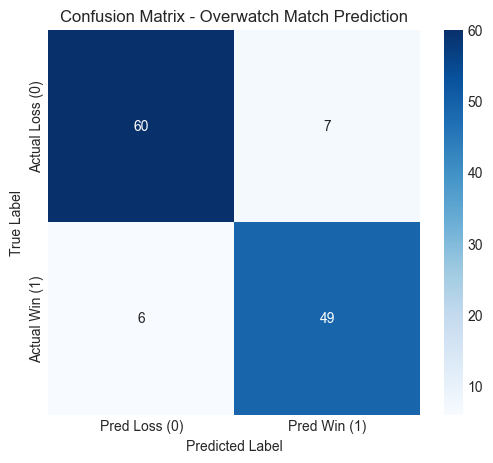

In [131]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# -------------------------
# Print metrics (clean format)
# -------------------------
print("="*50)
print("MODEL PERFORMANCE (Logistic Regression)")
print("="*50)
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"F1 Score : {f1*100:.2f}%")
print("="*50)

# -------------------------
# Confusion Matrix (Heatmap)
# -------------------------
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Loss (0)", "Pred Win (1)"],
    yticklabels=["Actual Loss (0)", "Actual Win (1)"]
)

plt.title("Confusion Matrix - Overwatch Match Prediction")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Coefficients

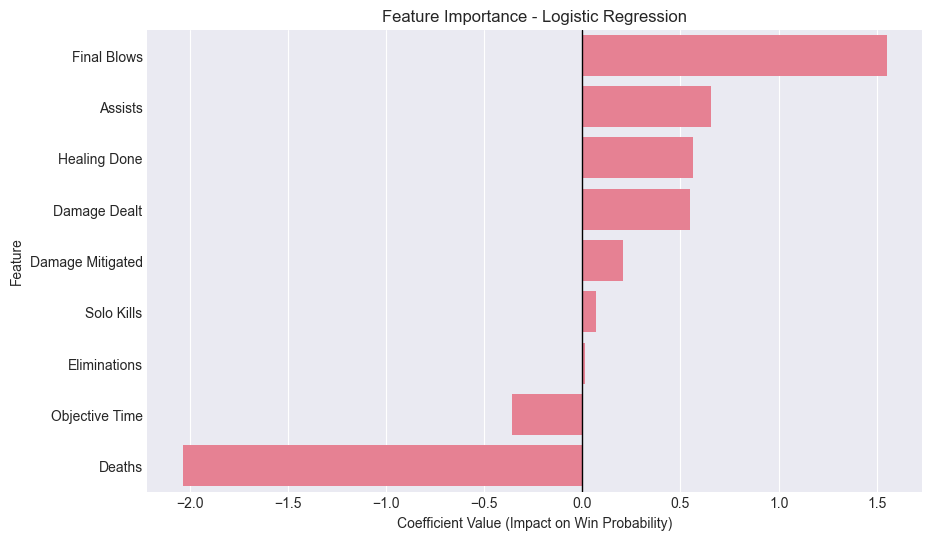

         Feature  Coefficient
     Final Blows     1.552853
         Assists     0.653994
    Healing Done     0.561375
    Damage Dealt     0.548382
Damage Mitigated     0.208883
      Solo Kills     0.070187
    Eliminations     0.012706
  Objective Time    -0.359002
          Deaths    -2.035509


In [132]:
coeffs = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Coefficient",
    y="Feature",
    data=coeffs
)

plt.title("Feature Importance - Logistic Regression")
plt.xlabel("Coefficient Value (Impact on Win Probability)")
plt.ylabel("Feature")

plt.axvline(0, color="black", linewidth=1)
plt.show()
print(coeffs.to_string(index=False))

In [133]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5, scoring="f1")
print("CV F1:", scores.mean())

CV F1: 0.9200773017357428


<b>What this tells us:</b>

Model has strong performance, accuracy is around 89%, F1 score is around 88%, with a Cross-Validation F1 score of 92%. While the CV F1 score was higher, it wasn't extremely different. This could be explained by having a harder random test split. Overall I am not concerned due to it being less than a 4% difference. Our scores tell us our model is accurate and has good generalization, stable behavior and low variance between training/testing splits. There does not seem to be any over or under fitting.

Our model made 122 predictions (20% of our total), 109 were correct (60 losses, 49 wins), with 12 incorrect predictions (7 losses predicted as a win, 6 wins predicted as a loss).

The most important stat is deaths. Having more deaths significanlty decreases your chances to win, with a coefficient of -2.04. This aligns strongly with Overwatch gameplay where teams work together, and missing a single person (20% of the team) could throw off a plan.
Final Blows was the second most important with a +1.55 coefficient. This is believable, because if nobody is getting the final hit after a team does damage to an enemy, that means they survived, are able to heal, and come back to fight again. Securing eliminations also increases the enemy's deaths, which as we see above has a significant negative impact to their likelihood of winning. Interestingly enough, eliminations themselves only had a coefficient of 0.01, which may be because Final Blows already basically covers this stat. This is called multicollinearity. Since so many stats are based around getting kills (Final Blows, Eliminations, Assists, Damage Dealt), I was not surprised to see this happen.
Assists were the next most important (coefficient of +0.65), again an assist means a kill happened, thus increasing the enemy's deaths.
Healing Done had a coefficient of +0.56. This also aligns with staying alive, and one could assume being healed more means staying alive more.
Damage Dealt, another stat aimed at kills, but also assists. Having a coefficient of +0.55 seems logical.
Objective Time is surprising at -0.36. This may show that a losing team tends to run to the objective to try to keep the game going, but it fails. It may also mean that dominant teams win fights quickly, thus lowering total objective time. High objective time may correlate with struggling on the defensive, unable to secure eliminations, versus being able to quickly secure eliminations leading to a much lower objective time.